<a href="https://colab.research.google.com/github/SANGRAMLEMBE/Computer_Vision_from_Scratch/blob/main/3_intro_to_weights_and_biases.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#  https://wandb.ai/sangram01-srm-institute-of-science-and-technology/5_flower_simple_neural_network?nw=nwusersangram01

In [ ]:
import wandb
from wandb.integration.keras import WandbMetricsLogger , WandbModelCheckpoint


import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras

In [ ]:
sweep_config = {
    'method': 'grid',
    'metric': {
      'name': 'val_accuracy',
      'goal': 'maximize'
    },
    'parameters': {
        'learning_rate': {'values': [0.001, 0.0001] },
        'batch_size': {'values': [8, 16] },
        'hidden_nodes': {'values': [128, 64] },
        'img_size':{'values':[16,224]},
        'epochs':{'values':[3,5]}
    }
}
sweep_id = wandb.sweep(sweep_config, project="5_flower_simple_neural_network")



/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: ERROR Invalid API key: API key must have 40+ characters, has 36.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

...

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


Create sweep with ID: zo68ovxo
Sweep URL: https://wandb.ai/sangram01-srm-institute-of-science-and-technology/5_flower_simple_neural_network/sweeps/zo68ovxo


In [ ]:
# from here we can access parameters

def train():
  with wandb.init() as run:
    config = wandb.config

    IMG_HEIGHT = config.img_size
    IMG_WIDTH = config.img_size
    IMG_CHANNELS = 3
    CLASS_NAMES = ["daisy", "dandelion", "roses", "sunflowers", "tulips"]



    def read_and_decode(filename, resize_dims):

      img_bytes = tf.io.read_file(filename)
      img = tf.image.decode_jpeg(img_bytes, channels = IMG_CHANNELS)
      img = tf.image.convert_image_dtype(img, tf.float32)
      img = tf.image.resize(img,resize_dims)

      return img

    def parse_csvline(csv_line):

      # record_default specify the data types for each column
      record_default = ["",""]
      filename, label_string = tf.io.decode_csv(csv_line, record_default)

      #Load the Image
      img  = read_and_decode(filename, [IMG_HEIGHT, IMG_WIDTH])

      # Convert label string to integer based on the CLASS_NAMES index
      label = tf.argmax(tf.math.equal(CLASS_NAMES, label_string))


      return img, label


    # Define datasets
    train_dataset = (
        tf.data.TextLineDataset("gs://practical-ml-vision-book-data/flowers_5_jpeg/flower_photos/train_set.csv")
        .map(parse_csvline, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(config.batch_size)
        .prefetch(tf.data.AUTOTUNE)
      )          # we defined batch size = 16

    eval_dataset = (
        tf.data.TextLineDataset("gs://practical-ml-vision-book-data/flowers_5_jpeg/flower_photos/train_set.csv")
        .map(parse_csvline, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(config.batch_size)
        .prefetch(tf.data.AUTOTUNE)
    )




    import matplotlib.pyplot as plt

    for image_batch, label_batch in train_dataset.take(2):

      #Take the first image from the batch
      first_image = image_batch[0]
      first_label = label_batch[0]


      # Conver Tensor To Numpy array
      plt.imshow(first_image.numpy())
      plt.title(f"Label:{CLASS_NAMES[first_label]}")
      plt.axis('off')
      plt.show()

    model= keras.Sequential([
        keras.layers.Flatten(input_shape = (IMG_HEIGHT, IMG_WIDTH,IMG_CHANNELS)),
        keras.layers.Dense(config.hidden_nodes, activation = "relu"),
        keras.layers.Dense(len(CLASS_NAMES), activation = "softmax")
    ])

    model.compile(
        optimizer = "adam",
        loss = keras.losses.SparseCategoricalCrossentropy(from_logits = False),
        metrics = ["accuracy"]
    )

    model.fit(
        train_dataset,
        validation_data = eval_dataset,
        epochs = config.epochs,
        callbacks = [
            WandbMetricsLogger(log_freq=5),]
    )




wandb: Agent Starting Run: 0wiiheux with config:
wandb: 	batch_size: 8
wandb: 	epochs: 3
wandb: 	hidden_nodes: 128
wandb: 	img_size: 224
wandb: 	learning_rate: 0.0001
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


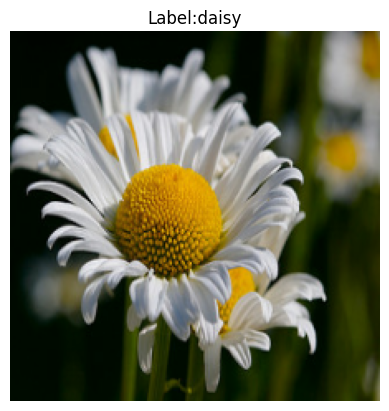

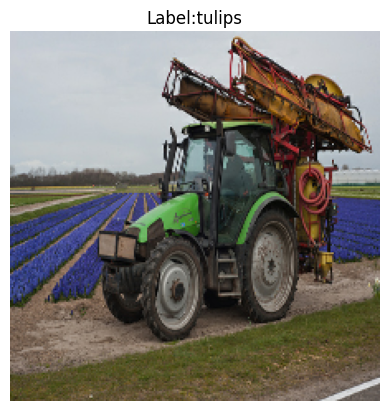

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/3
    413/Unknown 222s 533ms/step - accuracy: 0.2822 - loss: 13.7987

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


413/413 ━━━━━━━━━━━━━━━━━━━━ 381s 919ms/step - accuracy: 0.2997 - loss: 5.8840 - val_accuracy: 0.2470 - val_loss: 1.5685
Epoch 2/3
413/413 ━━━━━━━━━━━━━━━━━━━━ 363s 879ms/step - accuracy: 0.2479 - loss: 1.5794 - val_accuracy: 0.3370 - val_loss: 1.5411
Epoch 3/3
413/413 ━━━━━━━━━━━━━━━━━━━━ 372s 900ms/step - accuracy: 0.2600 - loss: 1.5923 - val_accuracy: 0.2615 - val_loss: 1.5820


batch/accuracy,▁▅▆▇▇████▆▆▆▆▆▆▆▆▆▆▆▆▆▇█▇▇▇▇▇▆▇▇▇▇▇▇▇▇▇▇
batch/batch_step,▁▁▁▁▁▂▂▂▂▂▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇██
batch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
batch/loss,██▆▅▄▄▄▃▃▃▃▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/accuracy,█▁▃
epoch/epoch,▁▅█
epoch/learning_rate,▁▁▁
epoch/loss,█▁▁
epoch/val_accuracy,▁█▂
epoch/val_loss,▆▁█
batch/accuracy,0.25973


wandb: Agent Starting Run: pm33wpgc with config:
wandb: 	batch_size: 8
wandb: 	epochs: 3
wandb: 	hidden_nodes: 64
wandb: 	img_size: 16
wandb: 	learning_rate: 0.001
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


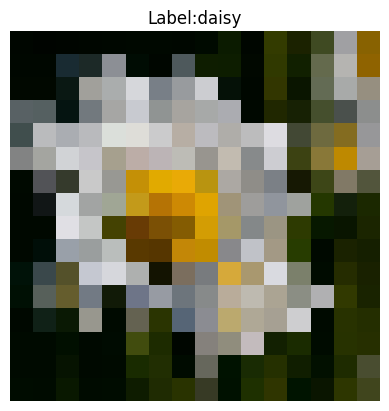

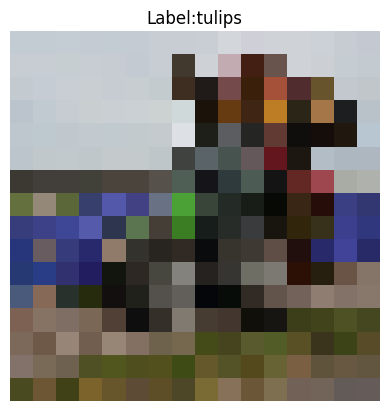

Epoch 1/3
413/413 ━━━━━━━━━━━━━━━━━━━━ 212s 512ms/step - accuracy: 0.3733 - loss: 1.4105 - val_accuracy: 0.4385 - val_loss: 1.2700
Epoch 2/3
413/413 ━━━━━━━━━━━━━━━━━━━━ 196s 475ms/step - accuracy: 0.4530 - loss: 1.2683 - val_accuracy: 0.4818 - val_loss: 1.1944
Epoch 3/3
413/413 ━━━━━━━━━━━━━━━━━━━━ 195s 472ms/step - accuracy: 0.4803 - loss: 1.2153 - val_accuracy: 0.5264 - val_loss: 1.1356


batch/accuracy,▁▂▂▃▄▄▄▄▄▅▅▆▆▆▆▆▆▆▆▆▆▅█▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇
batch/batch_step,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇█
batch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
batch/loss,███▅▅▅▅▅▅▅▁▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
epoch/accuracy,▁▆█
epoch/epoch,▁▅█
epoch/learning_rate,▁▁▁
epoch/loss,█▃▁
epoch/val_accuracy,▁▄█
epoch/val_loss,█▄▁
batch/accuracy,0.48114


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: c04mgosr with config:
wandb: 	batch_size: 8
wandb: 	epochs: 3
wandb: 	hidden_nodes: 64
wandb: 	img_size: 16
wandb: 	learning_rate: 0.0001
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


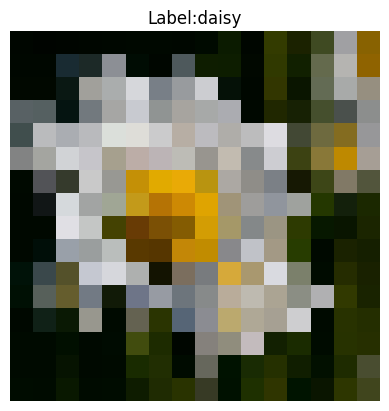

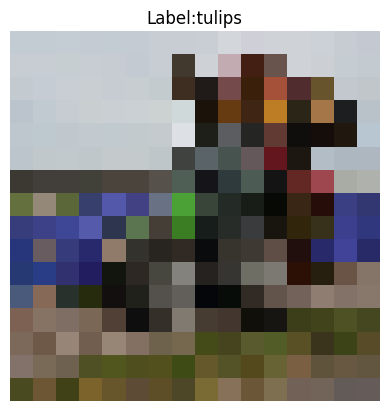

Epoch 1/3
    114/Unknown 30s 256ms/step - accuracy: 0.2735 - loss: 1.5866

In [ ]:
wandb.agent(sweep_id, function=train)